In [2]:
import numpy as np
import pandas as pd

In [1]:
import os
import requests
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")
import scipy
from shapely.geometry import LineString, Point

In [ ]:
import cv2
from scipy import ndimage
from spectral import *

def segmentation(bil, hdr, rotate_crop_params, savepath, lower_pixel_thresh=10000, upper_pixel_thresh=100000, band= 40, return_segment = False):
    '''
    =======================================
    == VISION SEGMENTATION OF HYPERCUBE  ==
    =======================================

    Inputs:
        bil:                  Path to the .bil hyperspectral datacube file
        hdr:                  Path to the .hdr hyperspectral datacube file
        rotate_crop_params:   User-defined dictionary of values used to rotate and crop the image. E.g., {'theta': -0.5, 'x1': 45, 'x2': 830, 'y1': 120, 'y2': 550}
        lower_pixel_thresh:   Elements containing fewer than the specified number of pixels will be removed
        upper_pixel_thresh:   Elements containing more than the specified number of pixels will be removed

    Outputs:
        data:                 An array containing the reflectance data extracted from the vision-segmented hyperspectral datacube
    '''

    # load spectral hypercube
    hypercube = envi.open(hdr, bil).load()  # load datacude
    singleband = hypercube[:, :, band]  # grab a single band to use for segmentation
    imshow(singleband)
    plt.title('Single Band')
    plt.show()
    singleband = (singleband / singleband.max() * 255).astype("uint8")
    # plot raw image
    imshow(hypercube, bands=(154, 78, 27))  # R: 154, G: 78, B: 27
    plt.title('Raw Image')
    plt.show()
    # crop/rotate single band
    singleband = ndimage.rotate(singleband, rotate_crop_params['theta'])  # reads image and rotates
    singleband = singleband[rotate_crop_params['y1']:rotate_crop_params['y2'],
                 rotate_crop_params['x1']:rotate_crop_params['x2']]  # crops image
    # crop/rotate hypercube
    hypercube = ndimage.rotate(hypercube, rotate_crop_params['theta'])  # reads image and rotates
    hypercube = hypercube[rotate_crop_params['y1']:rotate_crop_params['y2'],
                rotate_crop_params['x1']:rotate_crop_params['x2']]  # crops image
    # plot cropped image
    imshow(hypercube, bands=(154, 78, 27))  # R: 154, G: 78, B: 27
    plt.title('Cropped Image')
    plt.savefig(savepath+'/raw_image.png', dpi=300, bbox_inches='tight')
    plt.show()
    # transpose to segment along print direction
    singlebandT = ndimage.rotate(singleband, -90)
    hypercubeT = ndimage.rotate(hypercube, -90)
    # segment image with watershed
    watershed, edges = watershed_segment(singlebandT, small_elements_pixels=lower_pixel_thresh,
                                         large_elements_pixels=upper_pixel_thresh)
    # plot segmented image
    fig, ax = plt.subplots()
    ax.imshow(watershed.T, cmap='viridis')
    ax.invert_yaxis()
    plt.title('Segmented Image')
    plt.savefig(savepath+'/segmented_image.png', dpi=300, bbox_inches='tight')
    plt.show()
    # extract spectra from segmentation and format data
    idx_min = np.unique(watershed)[1:].min()
    idx_max = np.unique(watershed)[1:].max()
    idx_norms = []
    num_drop = len(np.unique(watershed)[1:])
    idx_ = 1
    for drop in np.unique(watershed)[1:]:  # iterate through all segmented droplets, excluding background=0
        coords = np.argwhere(watershed == drop)
        spectra_all_pixels = []
        pixel_X_coord = []
        pixel_Y_coord = []
        for coord in coords:
            pixel_spectrum = hypercubeT[coord[0], coord[1], :]
            spectra_all_pixels.append(pixel_spectrum)
            pixel_X_coord.append(coord[0])
            pixel_Y_coord.append(coord[1])
        idx_norm = (drop - idx_min) / (idx_max - idx_min)
        idx_norms.append(idx_norm)
        data = pd.DataFrame(np.concatenate(
            (np.array(pd.read_csv('/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2023–2026 First Solar/03 Inorganic_Discovery/03_Data/bandgap bowing/HS camera/wavelength.txt', sep='\t', header=None)[0]).reshape(1, -1), np.array(spectra_all_pixels))).T)
        data = data.rename(columns={0: 'wavelength'})
        pixel_coords = pd.DataFrame({'X_coord': pixel_X_coord,'Y_coord': pixel_Y_coord})
        idx = idx_ -1
        idx_ = idx_+1
        print(data)
        data.to_csv(f'{savepath}/pixel_reflectance_{idx}.csv')
        pixel_coords.to_csv(f'{savepath}/pixel_coordinates_{idx}.csv')
        tauc = data.iloc[:, 1:]
        wl = data.iloc[:, 0]

        # plot 
        # fig, ax = plt.subplots(figsize=(8, 4))
        # colormap = mpl.cm.get_cmap('viridis')
        # for i in range(tauc.shape[1]):
        #     rgba = colormap(1-idx_norm)
        #     ax.plot(wl,tauc.iloc[:,i] / np.max(tauc.iloc[:,i]),c=rgba)  # Normalize each spectrum for visualization
        
        # ax.grid(which='minor', color='gray',linestyle='--', alpha=0.35)
        # ax.grid(which='major', color='gray',linestyle='--', alpha=0.35)
        # ax.set_yticklabels([])
        # plt.xlabel(r'Wavelength, $\lambda$ (nm)')
        # plt.ylabel(r'Reflectance, $R$ (a.u.)')
        # fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=100), cmap=mpl.cm.viridis), ax=ax)
        # plt.title('Extracted Reflectance Spectra')
        # plt.savefig(f'{savepath}/pixel_reflectance_{idx}.png', dpi=300, bbox_inches='tight', transparent=True)
        # plt.show()
    
    if return_segment:
        return data, watershed.T,num_drop
    else:
        return data


# Sub-functions for segmentation()

def segment_on_dt(a, img, threshold):
    '''
    Implements watershed segmentation.

    Inputs:
        a:         Image input
        img:       Threshold binned image
        threshold: RGB threshold value

    Outputs:
        lbl:       Borders of segmented droplets
        wat:       Segmented droplets via watershed
        lab:       Indices of each segmented droplet
    '''
    # estimate the borders of droplets based on known and unknown background + foreground (computed using dilated and erode)
    kernel = np.ones((2, 2), np.uint8)  #default parameter: kernel = np.ones((2, 2), np.uint8)
    border = cv2.dilate(img, None, iterations=1)
#     border = cv2.erode(border, kernel)
    border = border - cv2.erode(border, kernel)
    # segment droplets via distance mapping and thresholding
    dt = cv2.distanceTransform(img, 2, 3)
    dt = ((dt - dt.min()) / (dt.max() - dt.min()) * 255).astype(np.uint8)
    _, dt = cv2.threshold(dt, threshold, 255, cv2.THRESH_BINARY)
    # dt = 255 - dt     ##adjust based on if using contrast enhancing
    # obtain the map of segmented droplets with corresponding indices
    lbl, ncc = ndimage.label(dt)
    lbl = lbl * (255 / (ncc + 1))
    lab = lbl 
    # Completing the markers now.
    lbl[border == 255] = 255
    lbl = lbl.astype(np.int32)
    a = cv2.cvtColor(a,cv2.COLOR_GRAY2BGR)  # we must convert grayscale to BGR because watershed only accepts 3-channel inputs
    wat = cv2.watershed(a, lbl)
    lbl[lbl == -1] = 0
    lbl = lbl.astype(np.uint8)
    return 255 - lbl, wat, lab  # return lab, the segmented and indexed droplets

def watershed_segment(image, small_elements_pixels=0, large_elements_pixels=999999):
    '''
    Applies watershed image segmentation to separate droplet pixels from background pixels.

    Inputs:
        image:                   Input droplet image to segment
        small_elements_pixels:   Removes small elements that contain fewer than the specified number of pixels.
        large_elements_pixels:   Removes large elements that contain more than the specified number of pixels.

    Outputs:
        water:                   Watershed segmented droplets
        labs:                    Edges to each watershed segmented droplet
    '''
    RGB_threshold = 0
    img = image.copy()
    img = 255 - img
    
    img_bin = cv2.GaussianBlur(img,(5,5),0) 
    _,img_bin = cv2.threshold(img_bin,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    _, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)
                               # threshold image using Otsu's binarization # https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
    #img_bin = cv2.morphologyEx(img, cv2.MORPH_CLOSE, np.ones((8, 8), dtype=int))
 
    img_bin = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, np.ones((4, 4), dtype=int))

    img_bin = cv2.erode(img_bin, np.ones((2, 2), np.uint8))
    
    result, water, labs = segment_on_dt(a=img, img=img_bin,
                                        threshold=RGB_threshold)  # segment droplets from background and return indexed droplets
    water = cv2.dilate(water.astype('uint8'), np.ones((4, 4), np.uint8))
    water = cv2.medianBlur(water,5) 
    # remove small/large elements
    uniq_full, uniq_counts = np.unique(water,
                                       return_counts=True)  # get all unique watershed indices with pixel counts
    large_elements = uniq_full[uniq_counts > large_elements_pixels]  # mask large elements based on number of pixels
    small_elements = uniq_full[uniq_counts < small_elements_pixels] # mask small elements based on number of pixels
    for n in range(len(large_elements)):
        water[water == large_elements[n]] = 0  # remove all large elements
    for n in range(len(small_elements)):
        water[water == small_elements[n]] = 0  # remove all small elements
    return water, labs

Computing Experiment Sample_2_03_12_26. . .


Computing Experiment Sample_2_03_12_26. . .


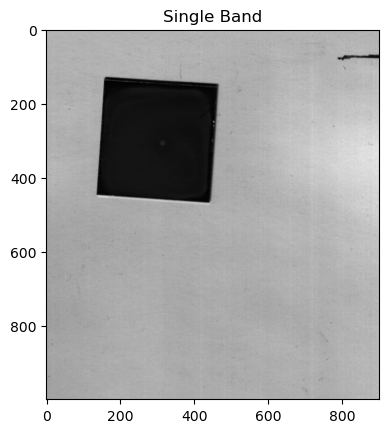

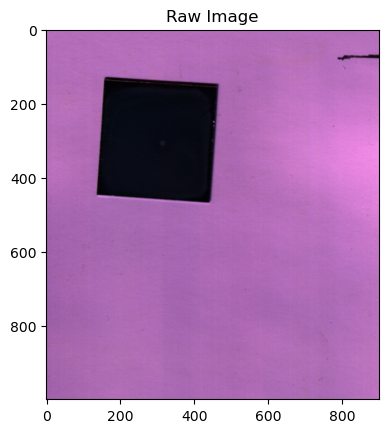

Computing Experiment Sample_2_03_12_26. . .


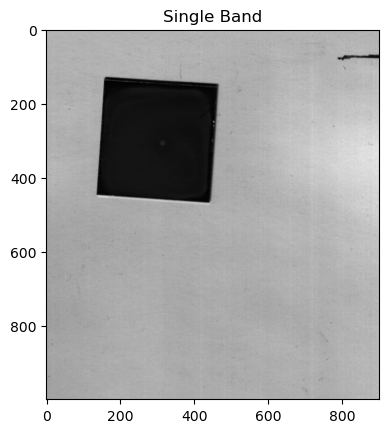

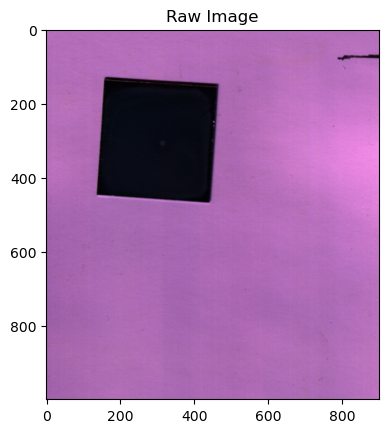

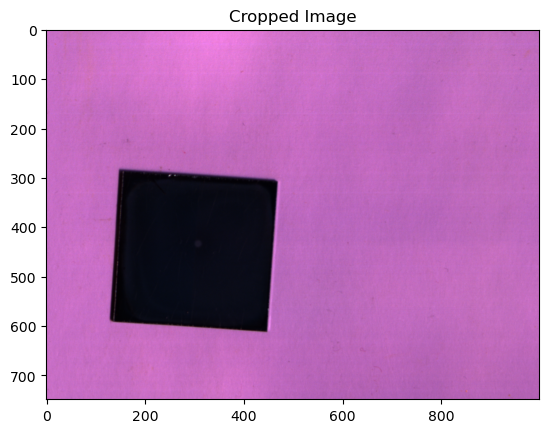

Computing Experiment Sample_2_03_12_26. . .


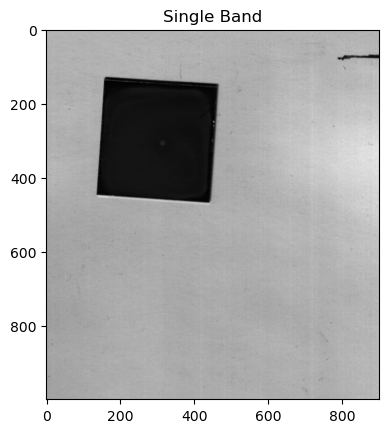

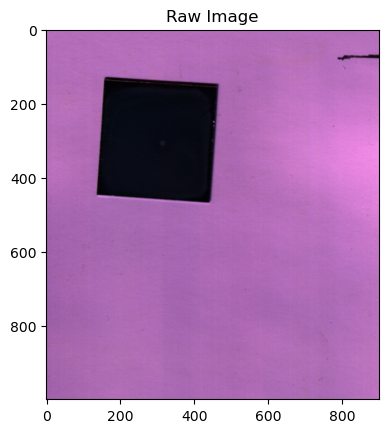

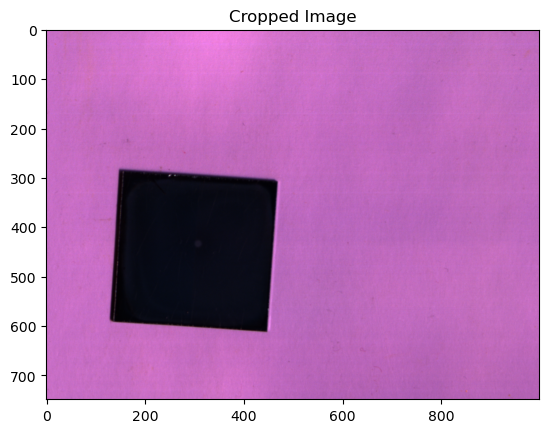

Unique segments found: [  0 127]
Segment pixel counts: [651235  97016]
Segments after filtering (excluding background): [127]


Computing Experiment Sample_2_03_12_26. . .


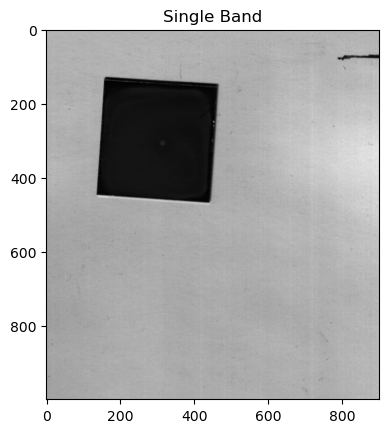

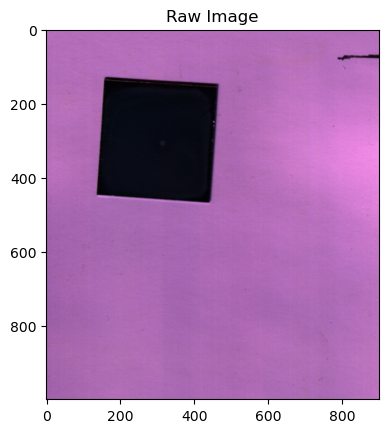

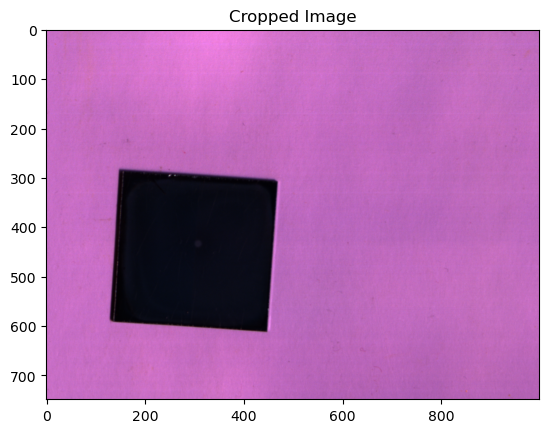

Unique segments found: [  0 127]
Segment pixel counts: [651235  97016]
Segments after filtering (excluding background): [127]


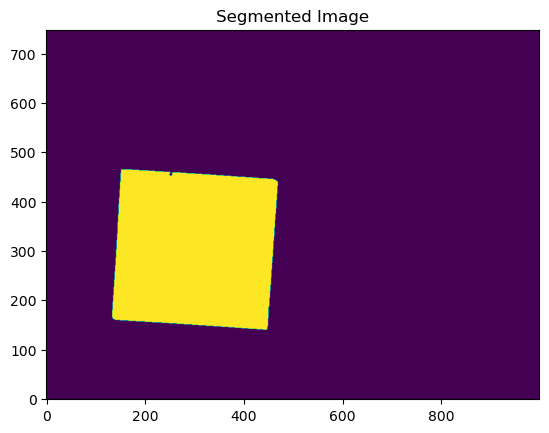

Computing Experiment Sample_2_03_12_26. . .


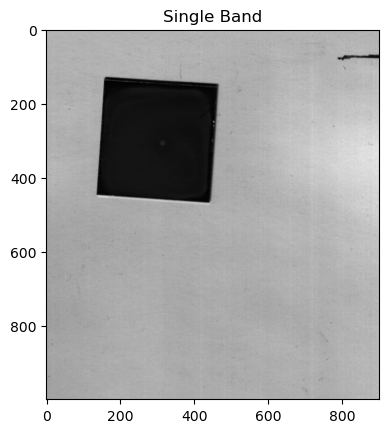

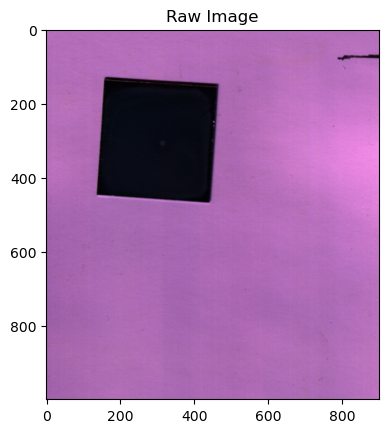

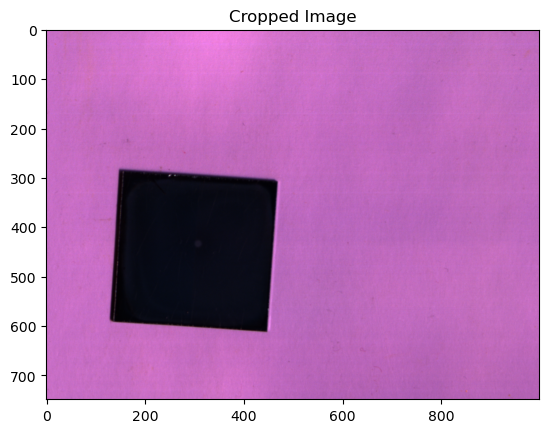

Unique segments found: [  0 127]
Segment pixel counts: [651235  97016]
Segments after filtering (excluding background): [127]


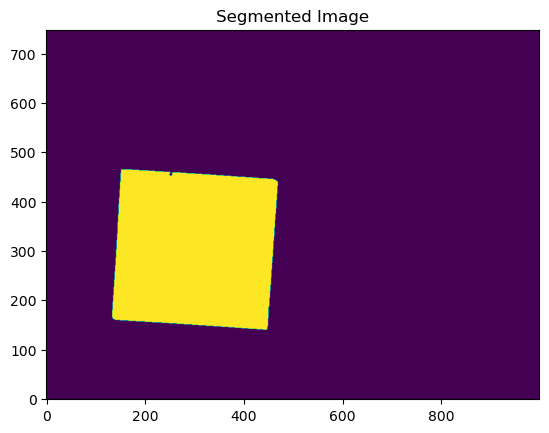

     wavelength       1       2       3       4       5       6       7  \
0        381.51  0.8012  0.8130  0.7723  0.6298  0.7278  0.8703  0.6317   
1        383.52  0.7781  0.8167  0.6666  0.7015  0.7492  0.4958  0.6514   
2        385.52  0.7435  0.6353  0.5441  0.6124  0.4629  0.5958  0.5392   
3        387.53  0.7862  0.6973  0.6289  0.5588  0.5880  0.5345  0.4974   
4        389.54  0.5478  0.1856  0.8059  0.5186  0.8767  0.6768  0.5368   
..          ...     ...     ...     ...     ...     ...     ...     ...   
295     1010.14  0.5605  0.5698  0.4829  0.5648  0.6326  0.4673  0.5258   
296     1012.40  0.4890  0.5592  0.5645  0.5442  0.5476  0.6304  0.4936   
297     1014.66  0.6047  0.5908  0.4769  0.5861  0.5248  0.5048  0.6059   
298     1016.92  0.6130  0.6242  0.5872  0.6118  0.5806  0.5951  0.6014   
299     1019.18  0.5062  0.5360  0.5477  0.5035  0.4833  0.5958  0.4755   

          8       9  ...   97007   97008   97009   97010   97011   97012  \
0    0.9630  0.7258  ..

In [ ]:
datapath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/05_Data/HSI/Perov on SAM'
savepath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/05_Data/HSI/Perov on SAM'
experiments = [
    'Sample_B_3_12_26'
]
for experiment in experiments:
    print(f'Computing Experiment {experiment}. . .')
    
    # read datacubes
    bil = f'{datapath}/{experiment}.bil'
    hdr = f'{datapath}/{experiment}.bil.hdr'
    rotate_crop_params = {'theta': 90, 'x1': 0, 'x2': -1, 'y1': 150, 'y2': -1} # USER DEFINED ROTATE/CROP PARAMETERS
    data, sgmnt,num_drop = segmentation(bil=bil, hdr=hdr, rotate_crop_params=rotate_crop_params, savepath=savepath, return_segment = True)
    print(num_drop)

In [2]:
from scipy import ndimage
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
from spectral import *
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1 import make_axes_locatable

def load_plt_setting():
    plt.style.use('seaborn-v0_8-white')
    mpl.rcParams['font.sans-serif'] = "Arial"
    mpl.rcParams['font.family'] = "sans-serif"
    mpl.rcParams['axes.linewidth'] = 2
    font = {'size': 32}
    mpl.rc('font', **font)
    mpl.rcParams['xtick.major.pad']='8'
    mpl.rcParams['ytick.major.pad']='8'
    plt.rcParams["font.weight"] = "normal"
    plt.rcParams["axes.labelweight"] = "normal"
    plt.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['axes.linewidth'] = 2

In [14]:
def read_films(film_idx, data_path, savepath):
    reflectance = pd.read_csv(f'{data_path}pixel_reflectance_{film_idx}.csv', header=None)
    coords = pd.read_csv(f'{data_path}pixel_coordinates_{film_idx}.csv', header=None)

    # Remove header rows and extract data properly
    coords = coords.iloc[1:].apply(pd.to_numeric, errors='coerce')
    spectra = reflectance.iloc[1:, 2:].apply(pd.to_numeric, errors='coerce').fillna(0)  # Skip wavelength column
    wavelength = reflectance.iloc[1:, 1].apply(pd.to_numeric, errors='coerce').values

    # Use pixel indices for exact correspondence
    valid_pixels = coords.dropna()
    pixel_ids = valid_pixels.iloc[:, 0].astype(int).values

    # Create DataFrame with exact pixel-spectrum correspondence
    df = pd.DataFrame({
    "pixel_id": pixel_ids,
    "x": valid_pixels.iloc[:, 1].values,
    "y": valid_pixels.iloc[:, 2].values,
    "spectrum": [spectra.iloc[:, pid].values for pid in pixel_ids]  # Use pixel_id as index
})

    # Create the plot
    # fig, ax = plt.subplots(figsize=(10, 6))
    # colormap = mpl.cm.get_cmap('RdPu')

    # # Plot each pixel spectrum with a different color
    spectra_array = np.array([df.iloc[i]['spectrum'] for i in range(len(df))]).T
    # n_pixels = len(df)
    # for i in range(n_pixels):
    #     # Normalize color index to [0, 1] range
    #     color_idx = i / (n_pixels - 1) if n_pixels > 1 else 0
    #     rgba = colormap(color_idx)
    
    #     # Normalize each spectrum for visualization (optional)
    #     spectrum = spectra_array[:, i]
    #     if np.max(spectrum) > 0:  # Avoid division by zero
    #         normalized_spectrum = spectrum-np.min(spectrum) / (np.max(spectrum)-np.min(spectrum))
    #     else:
    #         normalized_spectrum = spectrum
    
    #     ax.plot(wavelength, normalized_spectrum, c=rgba, linestyle='-', alpha=0.3, linewidth=0.8)

    # # Styling
    # ax.grid(which='minor', color='gray', linestyle='--', alpha=0.35)
    # ax.grid(which='major', color='gray', linestyle='--', alpha=0.35)
    # ax.set_xlabel(r'Wavelength, $\lambda$ (nm)')
    # ax.set_ylabel(r'Reflectance, $R$ (a.u.)')
    # ax.set_xlim(400, 900)

    # # Add colorbar
    # sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=n_pixels-1), cmap=colormap)
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax)
    # cbar.set_label('Pixel Index')

    # # plt.title(f'Film 0 - All Pixel Spectra (n={n_pixels})')
    # plt.tight_layout()
    # plt.savefig(f'{savepath}/film_{film_idx}_all_spectra.png', dpi=300)
    # plt.show()

    return df, spectra_array

In [4]:
# SPATIAL UNIFORMITY QUANTIFICATION PIPELINE
# SNV + SavGol → PCA → detrend → TV norm
# Import additional required libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter, detrend
from scipy import ndimage
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

# Step 1: SNV (Standard Normal Variate) Normalization
def apply_snv(spectra_matrix):
    """
    Apply Standard Normal Variate (SNV) normalization to spectra
    SNV removes multiplicative scatter effects and normalizes each spectrum
    """
    snv_spectra = np.zeros_like(spectra_matrix)
    
    for i in range(spectra_matrix.shape[1]):  # For each pixel
        spectrum = spectra_matrix[:, i]
        # SNV: (spectrum - mean) / std
        mean_spectrum = np.mean(spectrum)
        std_spectrum = np.std(spectrum)
        if std_spectrum > 0:  # Avoid division by zero
            snv_spectra[:, i] = (spectrum - mean_spectrum) / std_spectrum
        else:
            snv_spectra[:, i] = spectrum - mean_spectrum
    
    return snv_spectra

In [11]:
# Step 4: PC1 Score Detrending
# Remove spatial trends from PC1 scores to isolate local uniformity variations
def detrend_pc1_scores(df):
    """
    Detrend PC1 scores by removing linear spatial trends (plane fitting)
    
    Parameters:
    - df: DataFrame with columns ['x', 'y', 'pc1_score']
    
    Returns:
    - df_detrended: DataFrame with additional 'pc1_detrended' column
    - trend_coefficients: Coefficients of the fitted plane [intercept, x_slope, y_slope]
    """
    # Extract coordinates and PC1 scores
    x_coords = df['x'].values
    y_coords = df['y'].values
    pc1_values = df['pc1_score'].values
    
    # Create design matrix for plane fitting: [1, x, y]
    # This fits a plane: PC1 = intercept + x_slope*x + y_slope*y
    A = np.column_stack([np.ones(len(x_coords)), x_coords, y_coords])
    
    # Fit plane using least squares
    coefficients, residuals, rank, s = np.linalg.lstsq(A, pc1_values, rcond=None)
    intercept, x_slope, y_slope = coefficients
    
    # Calculate the fitted plane values for each point
    fitted_plane = intercept + x_slope * x_coords + y_slope * y_coords
    
    # Detrended PC1 scores = Original - Fitted plane
    pc1_detrended = pc1_values - fitted_plane
    
    # Create new DataFrame with detrended values
    df_detrended = df.copy()
    df_detrended['pc1_detrended'] = pc1_detrended
    df_detrended['fitted_trend'] = fitted_plane
    
    return df_detrended, coefficients

In [39]:
# Step 5: roughness calculation
def compute_roughness(df):
    """
    Compute the Roughness directly from DataFrame with coordinates and PC1 scores

    Parameters:
    - df: DataFrame with columns ['x', 'y', pc1_detrended]
    - pc1_column: Column name containing PC1 scores to analyze
    
    Returns:
    - Roughness value (RA) quantifying spatial uniformity
    - Spatial map created for visualization
    """
    # Create a spatial grid from the DataFrame
    x_coords = df['x'].values
    y_coords = df['y'].values
    pc1_values = df['pc1_detrended'].values
    x_min, x_max = int(np.min(x_coords))+10, int(np.max(x_coords))-5
    y_min, y_max = int(np.min(y_coords))+5, int(np.max(y_coords))-10
    
    # Create mask
    mask = ((x_coords >= x_min) & (x_coords <= x_max) &
            (y_coords >= y_min) & (y_coords <= y_max) &
            np.isfinite(pc1_values))
    x_f = x_coords[mask]
    y_f = y_coords[mask]
    pc1_f = pc1_values[mask]

    # grid bounds after cropping
    x_min_c, x_max_c = int(x_f.min()), int(x_f.max())
    y_min_c, y_max_c = int(y_f.min()), int(y_f.max())

    # Create spatial map
    spatial_map_shape = (y_max_c - y_min_c + 1, x_max_c - x_min_c + 1)
    spatial_map = np.full(spatial_map_shape, np.nan)
    
    # Fill spatial map with PC1 values
    for i, (pc1_val, x, y) in enumerate(zip(pc1_f, x_f, y_f)):
        if not (np.isnan(x) or np.isnan(y) or np.isnan(pc1_val)):
            row_idx = int(y) - y_min_c
            col_idx = int(x) - x_min_c
            if 0 <= row_idx < spatial_map_shape[0] and 0 <= col_idx < spatial_map_shape[1]:
                spatial_map[row_idx, col_idx] = pc1_val
    
    # Compute Roughness
    pc1_mean = np.mean(df['pc1_detrended'].values)
    ra_roughness = np.mean(np.abs(df['pc1_detrended'].values - pc1_mean))

    return ra_roughness, spatial_map



In [40]:
# Visualization
def plot_detrended_scores(spatial_map_detr, film_idx, save_path):
    load_plt_setting()
    fig, ax = plt.subplots(figsize=(12, 8))

    im = ax.imshow(spatial_map_detr, cmap='RdBu_r', origin='lower', aspect='equal')
    ax.set_title('Detrended PC1 Scores', pad = 30)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Detrended PC1', fontsize=22)
    plt.savefig(f'{save_path}/{film_idx}_detrended_pc1_scores.png', bbox_inches='tight')
    plt.show()


In [41]:
def uniformity_analysis_roughness(film_idx, datapath, savepath):
    df, spectra_array = read_films(film_idx, datapath, savepath)
    # step 1: SNV (Standard Normal Variate) Normalization
    # Y_snv = apply_snv(spectra_array)

    # Step 2: SavGol (Savitzky-Golay) Smoothing
    window_length = 21  # Must be odd and > 1
    polyorder = 3       # Must be < window_length
    Y_snv_savgol = savgol_filter(spectra_array, window_length=window_length, polyorder=polyorder, axis=0)

    # Step 3: PCA (Principal Component Analysis)
    # Transpose for PCA (samples x features format)
    # Each pixel is a sample, each wavelength is a feature
    spectra_for_pca = Y_snv_savgol.T  # Shape: (n_pixels, n_wavelengths)

    # Apply PCA
    n_components = min(10, spectra_for_pca.shape[1])  # Keep first 10 PCs or all if fewer
    pca = PCA(n_components=n_components)
    pca_scores = pca.fit_transform(spectra_for_pca)

    pc1_scores = pca_scores[:, 0]
    print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
    if len(pc1_scores) != len(df):
        raise ValueError(f"Length mismatch: pc1_scores={len(pc1_scores)} vs df={len(df)}")
    df = df.copy()
    df["pc1_score"] = pc1_scores

    # Step 4: Detrend PC1 scores
    df_detrended, coefficients = detrend_pc1_scores(df)
    df = df_detrended.copy()

    # Step 5: Calculate Ra: arithmetic mean of absolute deviations from mean
    ra_roughness, spatial_map_detr= compute_roughness(df)

    plot_detrended_scores(spatial_map_detr, film_idx, savepath)

    return ra_roughness

PC1 explains 56.1% of variance


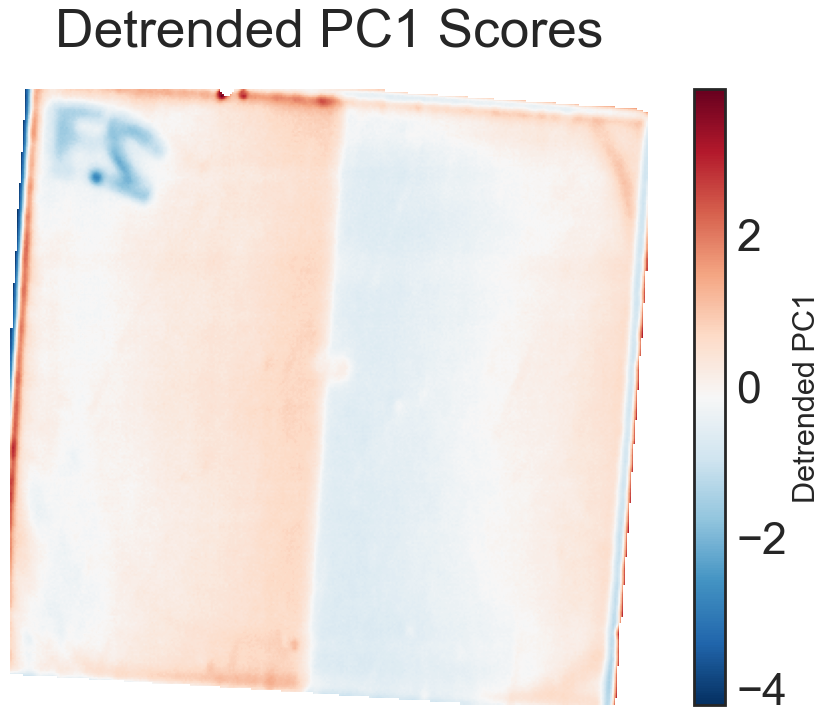

[0.408015923787552]


In [45]:
datapath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/05_Data/HSI/Perov on glass/Sample_2/'
savepath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/05_Data/HSI/Perov on glass/Sample_2/'
uniformity_list = []
uniformity_list.append(uniformity_analysis_roughness(0, datapath, savepath))

df_uniformity = pd.DataFrame({
    "film_id": range(len(uniformity_list)),
    "uniformity": uniformity_list
})
df_uniformity.to_csv(f"{savepath}/uniformity_individual_ra.csv", index=False)
print(uniformity_list)

In [22]:
datapath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/Rb3BiI6_BO_Round0_10_11/'
savepath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/Rb3BiI6_BO_Round0_10_11/'
uniformity_list = []
for film_idx in range(0, 6):
    uniformity_list.append(uniformity_analysis_roughness(film_idx, datapath, savepath))

df_uniformity = pd.DataFrame({
    "film_id": range(len(uniformity_list)),
    "uniformity": uniformity_list
})
df_uniformity.to_csv(f"{savepath}/uniformity_individual_ra.csv", index=False)

uniformity_avg =[]
uniformity_std =[]
group_size = 3
for i in range(0, len(uniformity_list), group_size):
    group = uniformity_list[i:i + group_size]

    uni_avg = np.mean(group)
    uni_std = np.std(group, ddof=1) 
    uniformity_avg.append(uni_avg)
    uniformity_std.append(uni_std)

    print(
        f'Group {i//group_size}: '
        f'Avg = {uni_avg:.3f}, Std = {uni_std:.3f}'
    )

df_cov = pd.DataFrame({
    "group_id": range(len(uniformity_avg)),
    "uniformity_avg": uniformity_avg,
    "uniformity_std": uniformity_std
})
print(df_cov)
df_cov.to_csv(f"{savepath}/uniformity_summary_ra.csv", index=False)

PC1 explains 85.4% of variance
PC1 explains 88.3% of variance
PC1 explains 89.7% of variance
PC1 explains 73.1% of variance
PC1 explains 69.4% of variance
PC1 explains 74.5% of variance
Group 0: Avg = 1.043, Std = 0.083
Group 1: Avg = 1.431, Std = 0.064
   group_id  uniformity_avg  uniformity_std
0         0        1.043394        0.082553
1         1        1.431095        0.064286
